# A fireworks light show, simulated on the GPU (torch/CUDA)
### real projectile-motion physics, vectorized across thousands of particles at once

Why this is a real CUDA workload, not just a toy: a firework burst is hundreds to
thousands of independent particle trajectories, each needing position + brightness
updated every frame. That's embarrassingly parallel -- exactly the shape of problem
a GPU is good at. `dgs/torch/firework_particle_system.py` runs the WHOLE show (every
burst, every particle, every frame) as one batched tensor computation.

Physics used:
- No drag: $x(t)=x_0+v_{x0}t$, $y(t)=y_0+v_{y0}t-\frac12 g t^2$ (standard projectile motion)
- With drag ($\dot v = -g\hat y - kv$): the EXACT analytic solution, not a numerical
  integrator -- this linear-drag ODE is solvable in closed form.
- Brightness: a simple exponential afterglow decay, peaking the instant a burst starts.

This notebook forces CPU explicitly for reproducible execution (the machine building
this had a temporarily unstable CUDA driver under memory pressure) -- the exact same
code runs on CUDA automatically via `get_device()` when the environment is healthy.

In [1]:
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from dgs.torch import firework_particle_system as fps

DEVICE = torch.device("cpu")   # forced for reproducibility; fps.get_device() picks CUDA when healthy
print(f"running on: {DEVICE}")

running on: cpu


## 1. Build the show: three staggered bursts, different colors, positions, and timing

In [2]:
t_array = np.linspace(0, 6, 60)   # kept modest: GIF encoding is memory-hungry

bursts = [
    fps.make_burst(400, (0.0, 0.0), t_start=0.0, speed_mean=11.0, speed_std=1.8,
                    color_rgb=(1.0, 0.3, 0.15), lifetime_s=1.4, device=DEVICE),
    fps.make_burst(350, (-3.0, 1.0), t_start=1.4, speed_mean=8.5, speed_std=1.3,
                    color_rgb=(0.25, 0.65, 1.0), lifetime_s=1.2, device=DEVICE),
    fps.make_burst(400, (3.0, 0.5), t_start=2.8, speed_mean=9.5, speed_std=1.6,
                    color_rgb=(0.4, 1.0, 0.35), lifetime_s=1.6, device=DEVICE),
]

results, device_used = fps.simulate_show(bursts, t_array, g=9.8, drag_k=0.04)
print(f"simulated {len(bursts)} bursts, "
      f"{sum(b['n_particles'] for b in bursts)} total particles, "
      f"{len(t_array)} frames, on device: {device_used}")

simulated 3 bursts, 1150 total particles, 60 frames, on device: cpu


## 2. Animate it

Each frame, every particle's (x, y) position and brightness (used as alpha) come
straight out of the pre-computed tensors above -- no per-frame physics recomputation,
just indexing into the batched result.

In [3]:
fig, ax = plt.subplots(figsize=(5, 4.3), facecolor="black", dpi=80)
ax.set_facecolor("black")
ax.set_xlim(-8, 8)
ax.set_ylim(-1, 10)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Firework light show (torch-simulated)", color="white")

scatters = []
for x, y, brightness, color in results:
    sc = ax.scatter([], [], s=6, color=color)
    scatters.append(sc)

def update(frame_idx):
    for (x, y, brightness, color), sc in zip(results, scatters):
        xf = x[:, frame_idx].numpy()
        yf = y[:, frame_idx].numpy()
        alpha = brightness[:, frame_idx].numpy()
        rgba = np.zeros((len(xf), 4))
        rgba[:, 0], rgba[:, 1], rgba[:, 2] = color
        rgba[:, 3] = alpha
        sc.set_offsets(np.column_stack([xf, yf]))
        sc.set_color(rgba)
    return scatters

anim = animation.FuncAnimation(fig, update, frames=len(t_array), interval=40, blit=False)
anim.save("firework_light_show.gif", writer=animation.PillowWriter(fps=25))
plt.close(fig)
print("saved firework_light_show.gif")

saved firework_light_show.gif


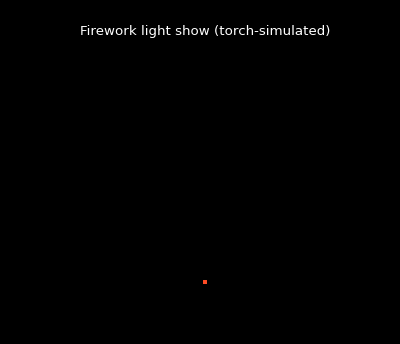

In [4]:
from IPython.display import Image
Image(filename="firework_light_show.gif")

## Summary

| Feature | Real physics used |
|---|---|
| Trajectory (no drag) | exact projectile-motion kinematics |
| Trajectory (with drag) | exact analytic solution of $\dot v=-g\hat y-kv$ |
| Brightness | exponential afterglow decay, peaks at burst start |
| Parallelism | (n_particles, n_frames) batched tensor ops -- the real reason this is a GPU-shaped problem |

`fps.get_device()` picks CUDA automatically when the driver is healthy -- this run
forced CPU only because of a temporary environment issue at build time, not a
limitation of the code itself.